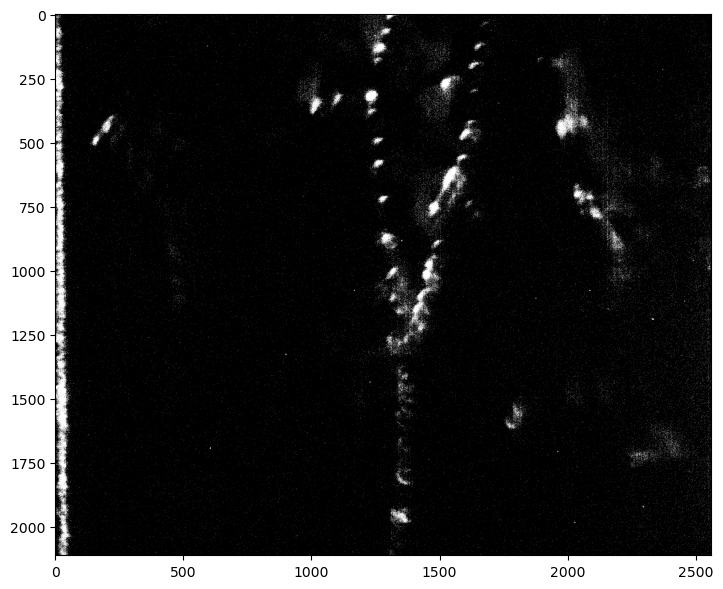

In [3]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from rocking_curve import load_edf_images, extract_patches, reconstruct_image_with_background, normalize_image
from model import CNN

device = torch.device("cuda" if torch.cuda.is_available() else "CPU")


#directory = "/home/esrf/benhadji/dfxm-go-ml/ex_data/"
#pat = directory + "Z_local_rocking_2x_{scan:02d}_{i:04d}.edf"
directory = "/data/projects/engage_id03/S1_590A_Al_200_ff_saturday/Al_111_rockinglayer_18/"
pat = directory + "Al_111_rockinglayer_{scan:02d}_{i:04d}.edf"

images = load_edf_images(directory, pat, scan=18, nb=31)

patch_size = (64, 64)

all_patches = []
shapes = []

for img in images:
    patches, img_shape = extract_patches(img, patch_size)
    all_patches.append(patches)
    shapes.append(img_shape)

all_patches_flat = np.concatenate([patches.reshape(-1) for patches in all_patches])
mean = all_patches_flat.mean()
std = all_patches_flat.std()

model = CNN(patch_size)
model.load_state_dict(torch.load("cnn_model.pth", map_location=device))
model = model.to(device)
model.eval()

def classify_patches(patches, model, mean, std, device):
    classified_labels = []
    for patch in patches:
        patch = (patch - mean) / std
        patch_tensor = torch.tensor(patch, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
        with torch.no_grad():
            output = model(patch_tensor)
            _, predicted = torch.max(output, 1)
            classified_labels.append(predicted.item())
    return classified_labels

classified_patches = []
for patches in all_patches:
    labels = classify_patches(patches, model, mean, std, device)
    classified_patches.append(labels)

mean_intensity = np.mean([np.mean(patch) for frame in all_patches for patch in frame])

reconstructed_images = []
for patches, labels, shape in zip(all_patches, classified_patches, shapes):
    reconstructed_img = reconstruct_image_with_background(patches, labels, shape, patch_size, mean_intensity)
    
    bg_mean = np.mean(reconstructed_img)
    bg_std = np.std(reconstructed_img)
    background_subtracted = reconstructed_img - (bg_mean + bg_std)
    background_subtracted[background_subtracted < 0] = 0

    p_max = np.percentile(background_subtracted, 98)
    if p_max > 0:
        background_subtracted /= p_max
        background_subtracted[background_subtracted > 1] = 1

    reconstructed_images.append(background_subtracted)

summed_image = np.sum(reconstructed_images, axis=0)

p_max = np.percentile(summed_image, 99)
if p_max > 0:
    final_image = summed_image / p_max
    final_image[final_image > 1] = 1
else:
    final_image = summed_image



binary_image = final_image > 0.7

plt.figure(figsize=(8, 6))
plt.imshow(binary_image, cmap='gray')
plt.axis('on')
plt.tight_layout()
plt.show()


**Unseen Data**

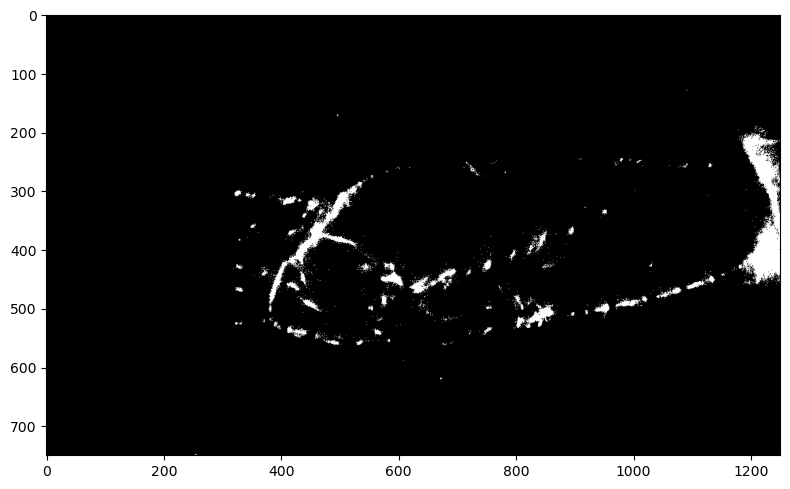

In [5]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from rocking_curve import load_edf_images, extract_patches, reconstruct_image_with_background, normalize_image
from model import CNN

device = torch.device("cuda" if torch.cuda.is_available() else "CPU")


directory = "/home/esrf/benhadji/dfxm-go-ml/ex_data/"
pat = directory + "Z_local_rocking_2x_{scan:02d}_{i:04d}.edf"

images = load_edf_images(directory, pat, scan=0o5, nb=11)

patch_size = (64, 64)

all_patches = []
shapes = []

for img in images:
    patches, img_shape = extract_patches(img, patch_size)
    all_patches.append(patches)
    shapes.append(img_shape)

all_patches_flat = np.concatenate([patches.reshape(-1) for patches in all_patches])
mean = all_patches_flat.mean()
std = all_patches_flat.std()

model = CNN(patch_size)
model.load_state_dict(torch.load("cnn_model.pth", map_location=device))
model = model.to(device)
model.eval()

def classify_patches(patches, model, mean, std, device):
    classified_labels = []
    for patch in patches:
        patch = (patch - mean) / std
        patch_tensor = torch.tensor(patch, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
        with torch.no_grad():
            output = model(patch_tensor)
            _, predicted = torch.max(output, 1)
            classified_labels.append(predicted.item())
    return classified_labels

classified_patches = []
for patches in all_patches:
    labels = classify_patches(patches, model, mean, std, device)
    classified_patches.append(labels)

mean_intensity = np.mean([np.mean(patch) for frame in all_patches for patch in frame])

reconstructed_images = []
for patches, labels, shape in zip(all_patches, classified_patches, shapes):
    reconstructed_img = reconstruct_image_with_background(patches, labels, shape, patch_size, mean_intensity)
    
    bg_mean = np.mean(reconstructed_img)
    bg_std = np.std(reconstructed_img)
    background_subtracted = reconstructed_img - (bg_mean + bg_std)
    background_subtracted[background_subtracted < 0] = 0

    p_max = np.percentile(background_subtracted, 98)
    if p_max > 0:
        background_subtracted /= p_max
        background_subtracted[background_subtracted > 1] = 1

    reconstructed_images.append(background_subtracted)

summed_image = np.sum(reconstructed_images, axis=0)

p_max = np.percentile(summed_image, 99)
if p_max > 0:
    final_image = summed_image / p_max
    final_image[final_image > 1] = 1
else:
    final_image = summed_image



binary_image = final_image > 0.7

x_start, x_end = 250, 1500
y_start, y_end = 750, 1500

roi_image = binary_image[y_start:y_end, x_start:x_end]

plt.figure(figsize=(8, 6))
plt.imshow(roi_image, cmap='gray')
plt.axis('on')
plt.tight_layout()
plt.show()